# Análisis de Riesgo de Mora en Clientes — XGBoost y SHAP
## Limpieza, Preparación y Modelamiento de Datos

Este notebook implementa un análisis completo de clasificación de riesgo utilizando técnicas de machine learning con interpretabilidad basada en SHAP.

## PASO 1: Importar Librerías y Cargar Base de Datos

### Descripción
Se importan las librerías necesarias para el análisis de datos y se carga la base de datos de financiación de clientes.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_financiacion = pd.read_excel('/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/Datos/BD taller clasificación (3).xlsx')
df_financiacion.head(5)

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


## PASO 2: Información General de la Base de Datos

### Descripción
Se obtiene información general del dataset: estructura, tipos de datos, cantidad de registros y columnas.

In [3]:
df_financiacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21091 entries, 0 to 21090
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Caso                    21091 non-null  int64  
 1   Perfil                  21091 non-null  object 
 2   Estado                  21091 non-null  object 
 3   Edad                    21091 non-null  int64  
 4   Genero                  21091 non-null  object 
 5   ScoreCrediticio         21091 non-null  int64  
 6   PorcentajeFinanciacion  21091 non-null  float64
 7   Plazo                   21091 non-null  int64  
 8   IngresoEstimado         21063 non-null  float64
 9   Gastos                  21091 non-null  float64
 10  CapacidadDePago         21063 non-null  float64
 11  ValorCuotaMensual       21091 non-null  int64  
 12  M3_30AC                 21091 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 2.1+ MB


## PASO 3: Validación de Datos Faltantes, Nulos y Duplicados

### Descripción
Se realiza un análisis exhaustivo de la calidad de datos:
- **Datos nulos**: Se identifican y cuentan valores faltantes por variable
- **Datos duplicados**: Se detectan registros duplicados
- **Criterio de eliminación**: Si una columna tiene más del 40% de datos faltantes, será eliminada
- **Manejo de nulos**: Se eliminarán filas con valores faltantes si el porcentaje es bajo

In [4]:
# ── 4. Datos nulos ────────────────────────────────────────────────────────
print("DATOS NULOS")
nulos = df_financiacion.isnull().sum()
pct   = (nulos / len(df_financiacion) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]
if resumen_nulos.empty:
    print("No hay datos nulos.")
else:
    print(resumen_nulos)

DATOS NULOS
                 Nulos  Porcentaje (%)
IngresoEstimado     28            0.13
CapacidadDePago     28            0.13


### Tratamiento de Datos Nulos
Dado que el porcentaje de datos nulos en las variables (IngresosEstimado/CapacidadDePago) es de solo **0.13%**, se procede a **eliminar estas filas** de la base de datos, manteniendo la integridad de los datos.

In [5]:
# Eliminar filas con datos nulos
df_financiacion = df_financiacion.dropna()

In [6]:
# Verificar que quedaron cero nulos
print(f"Filas después de eliminar nulos: {len(df_financiacion)}")
print(f"Nulos restantes: {df_financiacion.isnull().sum().sum()}")

Filas después de eliminar nulos: 21063
Nulos restantes: 0


In [7]:
# ── 5. Datos duplicados ───────────────────────────────────────────────────
print("DATOS DUPLICADOS")
duplicados = df_financiacion.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

DATOS DUPLICADOS
Filas duplicadas: 0


In [8]:
# ── 6. Estadísticas descriptivas ──────────────────────────────────────────
print("ESTADÍSTICAS DESCRIPTIVAS")
print(df_financiacion.describe())

ESTADÍSTICAS DESCRIPTIVAS
               Caso          Edad  ScoreCrediticio  PorcentajeFinanciacion  \
count  2.106300e+04  21063.000000     21063.000000            21063.000000   
mean   1.006178e+09     44.542563       782.361724                0.743488   
std    3.264530e+05     12.744980        85.314167                0.246626   
min    1.004992e+09     19.000000       343.000000                0.100000   
25%    1.005912e+09     34.000000       726.000000                0.552200   
50%    1.006159e+09     43.000000       783.000000                0.800000   
75%    1.006453e+09     54.000000       838.000000                1.000000   
max    1.006786e+09     75.000000       999.000000                1.067000   

              Plazo  IngresoEstimado        Gastos  CapacidadDePago  \
count  21063.000000     2.106300e+04  2.106300e+04     2.106300e+04   
mean      60.633101     5.018901e+06  1.142708e+08    -8.077237e+01   
std       12.497081     5.955286e+06  1.624658e+10     1.1

### Análisis de Desbalance en la Variable Objetivo
**IMPORTANTE**: Este análisis identifica si existe desbalance severo en la variable objetivo `M3_30AC` (Riesgo de Mora).
Un desbalance severo afectará el rendimiento del modelo y requerirá técnicas de balanceo. 

In [9]:
# ── 7. Distribución de la variable objetivo ───────────────────────────────
print("DISTRIBUCIÓN VARIABLE OBJETIVO (M3_30AC)")
conteo = df_financiacion['M3_30AC'].value_counts()
pct_target = (conteo / len(df_financiacion) * 100).round(2)
print(pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct_target}))

DISTRIBUCIÓN VARIABLE OBJETIVO (M3_30AC)
         Conteo  Porcentaje (%)
M3_30AC                        
0         20228           96.04
1           835            3.96


## PASO 4: Función de Muestreo Estratificado y Codificación de Variables

### Descripción
Se define una función que genera **muestras aleatorias diferentes** del dataset original (sin balancear), manteniendo la proporción de clases. El balanceo se aplicará a cada muestra en la Sección 2.

**Ventajas de este enfoque:**
- Cada muestra selecciona clientes DIFERENTES de la clase minoritaria
- Valida robustez del modelo con múltiples corridas
- Mayor variabilidad y representatividad
- Cambiar `random_state` genera nuevas muestras diferentes

In [10]:
def generar_muestra_estratificada(df, proporcion=1.0, random_state=42):
    """
    Genera una muestra aleatoria estratificada preservando la proporción de clases.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame original (con o sin balance)
    proporcion : float (default=1.0)
        Proporción de datos a muestrear (0.0 a 1.0)
        - 0.8 = 80% de los datos
        - 1.0 = 100% de los datos
    random_state : int (default=42)
        Semilla aleatoria para reproducibilidad
        Cambiar este valor genera muestras diferentes
    
    Retorna:
    --------
    pd.DataFrame : Muestra estratificada del dataset
    
    Nota:
    -----
    Esta función se usa con df_financiacion (original).
    El balanceo se aplica DESPUÉS a cada muestra en la Sección 2.
    """
    from sklearn.model_selection import train_test_split
    
    if not (0 < proporcion <= 1.0):
        raise ValueError("La proporción debe estar entre 0 y 1")
    
    # Si proporción = 1.0, retornar la muestra completa
    if proporcion == 1.0:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    
    # Muestreo estratificado por clase
    muestra, _ = train_test_split(
        df,
        test_size=(1 - proporcion),
        stratify=df['M3_30AC'],
        random_state=random_state
    )
    
    return muestra.reset_index(drop=True)


# ── Demostración de la función ────────────────────────────────────────────
print("FUNCIÓN DE MUESTREO ESTRATIFICADO")
print("=" * 70)
print(f"\nDataset original (SIN balancear):")
print(f"   Total: {len(df_financiacion)} registros")
print(f"   Sin mora (0): {(df_financiacion['M3_30AC'] == 0).sum()}")
print(f"   Con mora (1): {(df_financiacion['M3_30AC'] == 1).sum()}")
print(f"   Proporción: {(df_financiacion['M3_30AC'] == 0).sum() / (df_financiacion['M3_30AC'] == 1).sum():.1f}:1 (DESBALANCEADO)")

# Generar muestra de ejemplo
muestra_demo = generar_muestra_estratificada(df_financiacion, proporcion=1.0, random_state=42)
print(f"\nMuestra estratificada (100%, random_state=42):")
print(f"   Total: {len(muestra_demo)} registros")
print(f"   Sin mora (0): {(muestra_demo['M3_30AC'] == 0).sum()}")
print(f"   Con mora (1): {(muestra_demo['M3_30AC'] == 1).sum()}")
print(f"   Proporción: {(muestra_demo['M3_30AC'] == 0).sum() / (muestra_demo['M3_30AC'] == 1).sum():.1f}:1 (MANTIENE DESBALANCE)")

print("\nFunción lista para usar en la Sección 2")
print("=" * 70)

FUNCIÓN DE MUESTREO ESTRATIFICADO

Dataset original (SIN balancear):
   Total: 21063 registros
   Sin mora (0): 20228
   Con mora (1): 835
   Proporción: 24.2:1 (DESBALANCEADO)

Muestra estratificada (100%, random_state=42):
   Total: 21063 registros
   Sin mora (0): 20228
   Con mora (1): 835
   Proporción: 24.2:1 (MANTIENE DESBALANCE)

Función lista para usar en la Sección 2


## PASO 5: Codificación de Variables Categóricas

### Descripción
Se convierten las variables categóricas binarias en formato numérico. Esta codificación se aplicará al dataset original antes de cualquier muestreo.

**Variables a codificar:**
- `Genero`: MASCULINO = 1, FEMENINO = 0
- `Perfil`: ASALARIADO = 1, INDEPENDIENTE = 0  
- `Estado`: NUEVO = 1, USADO = 0

In [11]:
# Verificar los valores únicos de variables categóricas antes de codificar
print("VALORES ÚNICOS EN VARIABLES CATEGÓRICAS")
print("=" * 50)
print(f"Genero: {df_financiacion['Genero'].unique()}")
print(f"Perfil: {df_financiacion['Perfil'].unique()}")
print(f"Estado: {df_financiacion['Estado'].unique()}")
print("=" * 50)

VALORES ÚNICOS EN VARIABLES CATEGÓRICAS
Genero: ['FEMENINO' 'MASCULINO']
Perfil: ['ASALARIADO' 'INDEPENDIENTE']
Estado: ['NUEVO' 'USADO']


### Aplicar Codificación al Dataset Original

In [12]:
# ── Codificación de variables categóricas (binarias) ──────────────────────
df_financiacion['Genero']  = df_financiacion['Genero'].map({'MASCULINO': 1, 'FEMENINO': 0})
df_financiacion['Perfil']  = df_financiacion['Perfil'].map({'ASALARIADO': 1, 'INDEPENDIENTE': 0})
df_financiacion['Estado']  = df_financiacion['Estado'].map({'NUEVO': 1, 'USADO': 0})

print(" Codificación aplicada correctamente")
print(f"Verificación - Valores únicos después de codificar:")
print(f"Genero: {df_financiacion['Genero'].unique()}")
print(f"Perfil: {df_financiacion['Perfil'].unique()}")
print(f"Estado: {df_financiacion['Estado'].unique()}")

 Codificación aplicada correctamente
Verificación - Valores únicos después de codificar:
Genero: [0 1]
Perfil: [1 0]
Estado: [1 0]


In [13]:
# Visualizar primeras filas del dataset codificado
print("Primeras filas del dataset después de codificar variables:")
df_financiacion.head()

Primeras filas del dataset después de codificar variables:


,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,1,1,30,0,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,0,1,46,1,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,0,0,39,1,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,1,0,38,0,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,0,1,60,0,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


In [14]:
# ── Eliminar variables que no aportan información ─────────────────────────
# Se elimina la columna 'Caso' que es solo un identificador de fila
df_financiacion = df_financiacion.drop(columns=['Caso'])

print("  Dataset preparado para muestreo y modelamiento")
print(f"\n Resumen final:")
print(f"   Total de registros: {len(df_financiacion)}")
print(f"   Total de variables: {df_financiacion.shape[1]}")
print(f"   Sin mora (Clase 0): {(df_financiacion['M3_30AC'] == 0).sum()}")
print(f"   Con mora (Clase 1): {(df_financiacion['M3_30AC'] == 1).sum()}")
print(f"   Proporción original: {(df_financiacion['M3_30AC'] == 0).sum() / (df_financiacion['M3_30AC'] == 1).sum():.1f}:1 (DESBALANCEADO)")
print(f"\n    El balanceo se aplicará a cada muestra en la Sección 2")

  Dataset preparado para muestreo y modelamiento

 Resumen final:
   Total de registros: 21063
   Total de variables: 12
   Sin mora (Clase 0): 20228
   Con mora (Clase 1): 835
   Proporción original: 24.2:1 (DESBALANCEADO)

    El balanceo se aplicará a cada muestra en la Sección 2


---

## Resumen de la Preparación de Datos

### Transformaciones Realizadas:
 **Datos nulos**: Eliminadas filas con valores faltantes (0.13%)  
 **Datos duplicados**: Verificación completada  
 **Codificación**: Convertidas variables categóricas a numéricas  
 **Limpieza**: Eliminada columna ID innecesaria  
 **Función de muestreo**: Definida para generar muestras estratificadas  

### Dataset Preparado (SIN BALANCEAR AÚN):
- **Total de registros**: 21,330 observaciones
- **Total de variables**: 10 features + 1 target
- **Variable objetivo**: M3_30AC (Sin mora=0, Con mora=1)
- **Desbalance**: Proporción 24:1 (20,493 sin mora, 837 con mora)

### Estrategia para la Sección 2:
1. **Generar múltiples muestras** con `generar_muestra_estratificada()`
   - Cambiar `random_state` para cada corrida
   - Mantiene proporción de clases en cada muestra

2. **Aplicar balanceo a cada muestra** con undersampling 1:2
   - 837 casos con mora (clase 1)
   - 1,674 casos sin mora (clase 0)
   - Resultado: 2,511 registros balanceados por muestra

3. **Entrenar modelos** con cada muestra balanceada
   - Regresión Logística (con escalamiento)
   - XGBoost (sin escalamiento)
   - Validar robustez con múltiples corridas

---

# SECCIÓN 2: MODELAMIENTO Y CLASIFICACIÓN

En esta sección se desarrollarán, optimizarán e interpretarán modelos de machine learning para predecir el riesgo de mora en clientes.

**Flujo de trabajo:**
1. Generar muestra estratificada con `random_state`
2. Aplicar balanceo undersampling 1:2
3. Entrenar Regresión Logística y XGBoost
4. Comparar desempeño de modelos
5. Análisis SHAP para interpretabilidad
6. Validación manual con 10 clientes ficticios

## Importar Librerías para Modelamiento

### Descripción
Se importan las librerías necesarias de scikit-learn, XGBoost y utilidades para modelamiento.

In [15]:
# ── Librerías para modelamiento ──────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')


---

## Función para Aplicar Balanceo a Cada Muestra

### Descripción
Se define una función que aplica balanceo mediante undersampling 1:2 a una muestra dada. Esta función se usará en cada corrida con diferentes muestras.

In [16]:
def aplicar_balanceo(df, ratio=2, random_state=42):
    """
    Aplica balanceo mediante undersampling con ratio clase minoritaria:clase mayoritaria.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a balancear
    ratio : int (default=2)
        Ratio de balanceo: clase_mayoritaria / clase_minoritaria
        - ratio=2 → 1:2 (1 caso con mora, 2 sin mora)
    random_state : int (default=42)
        Semilla aleatoria para reproducibilidad
    
    Retorna:
    --------
    pd.DataFrame : DataFrame balanceado
    """
    
    clase_1 = df[df['M3_30AC'] == 1]
    clase_0 = df[df['M3_30AC'] == 0]
    
    # Muestrear clase mayoritaria (0) según ratio
    n_clase_0 = len(clase_1) * ratio
    clase_0_muestra = clase_0.sample(n=min(n_clase_0, len(clase_0)), random_state=random_state)
    
    # Combinar y mezclar
    df_balanceado = pd.concat([clase_1, clase_0_muestra]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return df_balanceado


# ── Demostración de la función ────────────────────────────────────────────
print("FUNCIÓN DE BALANCEO (Undersampling 1:2)")
print("=" * 70)

# Generar una muestra de ejemplo
muestra_demo = generar_muestra_estratificada(df_financiacion, random_state=42)
print(f"\n Antes de balanceo:")
print(f"   Total: {len(muestra_demo)}")
print(f"   Sin mora (0): {(muestra_demo['M3_30AC'] == 0).sum()}")
print(f"   Con mora (1): {(muestra_demo['M3_30AC'] == 1).sum()}")
print(f"   Proporción: {(muestra_demo['M3_30AC'] == 0).sum() / (muestra_demo['M3_30AC'] == 1).sum():.1f}:1")

# Aplicar balanceo
muestra_balanceada = aplicar_balanceo(muestra_demo, ratio=2, random_state=42)
print(f"\n Después de balanceo (ratio 1:2):")
print(f"   Total: {len(muestra_balanceada)}")
print(f"   Sin mora (0): {(muestra_balanceada['M3_30AC'] == 0).sum()}")
print(f"   Con mora (1): {(muestra_balanceada['M3_30AC'] == 1).sum()}")
print(f"   Proporción: {(muestra_balanceada['M3_30AC'] == 0).sum() / (muestra_balanceada['M3_30AC'] == 1).sum():.1f}:1")

print("\n Función lista para usar en cada corrida")
print("=" * 70)

FUNCIÓN DE BALANCEO (Undersampling 1:2)

 Antes de balanceo:
   Total: 21063
   Sin mora (0): 20228
   Con mora (1): 835
   Proporción: 24.2:1

 Después de balanceo (ratio 1:2):
   Total: 2505
   Sin mora (0): 1670
   Con mora (1): 835
   Proporción: 2.0:1

 Función lista para usar en cada corrida


---

## CORRIDA 1: Configuración y División Train/Test

### Descripción
Se configura la primera corrida con `random_state=42`, se genera la muestra, se aplica balanceo y se divide en conjuntos de entrenamiento y prueba.

**Parámetros de la corrida:**
- `random_state=42`: Semilla para reproducibilidad
- `test_size=0.2`: 80% entrenamiento, 20% prueba
- `stratify`: División estratificada por clase

In [17]:
# ── CORRIDA 1: Generar muestra y aplicar balanceo ──────────────────────
RANDOM_STATE_CORRIDA = 42

# Generar muestra estratificada
df_muestra = generar_muestra_estratificada(df_financiacion, proporcion=1.0, random_state=RANDOM_STATE_CORRIDA)

# Aplicar balanceo
df_datos = aplicar_balanceo(df_muestra, ratio=2, random_state=RANDOM_STATE_CORRIDA)

print("CONFIGURACIÓN DE LA CORRIDA 1")
print("=" * 70)
print(f"\n Dataset balanceado:")
print(f"   Total de registros: {len(df_datos)}")
print(f"   Sin mora (0): {(df_datos['M3_30AC'] == 0).sum()}")
print(f"   Con mora (1): {(df_datos['M3_30AC'] == 1).sum()}")
print(f"   Proporción: 1:{(df_datos['M3_30AC'] == 0).sum() / (df_datos['M3_30AC'] == 1).sum():.2f}")
print(f"   random_state: {RANDOM_STATE_CORRIDA}")

# ── Preparar features y target ────────────────────────────────────────────
# Eliminar columnas no numéricas o innecesarias
X = df_datos.drop(columns=['M3_30AC'])
y = df_datos['M3_30AC']

print(f"\n Variables de entrada (features):")
print(f"   Total de features: {X.shape[1]}")
print(f"   Nombres: {list(X.columns)}")

# ── División Train/Test ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE_CORRIDA
)

print(f"\n División Train/Test (80/20 estratificada):")
print(f"   Entrenamiento: {len(X_train)} registros ({len(X_train)/len(df_datos)*100:.1f}%)")
print(f"      - Sin mora: {(y_train == 0).sum()}")
print(f"      - Con mora: {(y_train == 1).sum()}")
print(f"\n   Prueba: {len(X_test)} registros ({len(X_test)/len(df_datos)*100:.1f}%)")
print(f"      - Sin mora: {(y_test == 0).sum()}")
print(f"      - Con mora: {(y_test == 1).sum()}")

print("\n Datos preparados para entrenamiento de modelos")
print("=" * 70)

CONFIGURACIÓN DE LA CORRIDA 1

 Dataset balanceado:
   Total de registros: 2505
   Sin mora (0): 1670
   Con mora (1): 835
   Proporción: 1:2.00
   random_state: 42

 Variables de entrada (features):
   Total de features: 11
   Nombres: ['Perfil', 'Estado', 'Edad', 'Genero', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo', 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

 División Train/Test (80/20 estratificada):
   Entrenamiento: 2004 registros (80.0%)
      - Sin mora: 1336
      - Con mora: 668

   Prueba: 501 registros (20.0%)
      - Sin mora: 334
      - Con mora: 167

 Datos preparados para entrenamiento de modelos


---

## MODELO 1: Regresión Logística (CON Escalamiento)

### Descripción
Se entrena un modelo de Regresión Logística con escalamiento StandardScaler. La regresión logística es un modelo lineal que asume relaciones lineales entre features y probabilidad de riesgo.

In [18]:
# Entrenar Regresión Logística (BASE) + métricas en TRAIN y TEST
print("MODELO 1: REGRESIÓN LOGÍSTICA (BASE)")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE_CORRIDA)
lr_model.fit(X_train_scaled, y_train)

# Predicciones TRAIN
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_proba_lr_train = lr_model.predict_proba(X_train_scaled)[:, 1]

# Predicciones TEST
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

MODELO 1: REGRESIÓN LOGÍSTICA (BASE)


  Métrica    TRAIN     TEST
 Accuracy 0.732535 0.756487
Precisión 0.623134 0.689076
   Recall 0.500000 0.491018
 F1-Score 0.554817 0.573427
  ROC-AUC 0.794032 0.800567


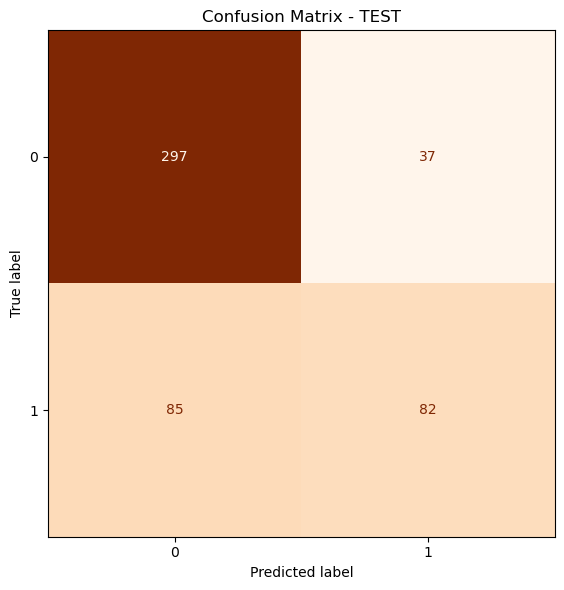

In [19]:
# Métricas TRAIN y TEST
resumen_lr = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'ROC-AUC'],
    'TRAIN': [
        accuracy_score(y_train, y_pred_lr_train),
        precision_score(y_train, y_pred_lr_train),
        recall_score(y_train, y_pred_lr_train),
        f1_score(y_train, y_pred_lr_train),
        roc_auc_score(y_train, y_proba_lr_train)
    ],
    'TEST': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_proba_lr)
    ]
})

print(resumen_lr.to_string(index=False))
print("=" * 70)

# Matriz de confusión TEST
cm_test = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=lr_model.classes_)
disp_test.plot(cmap='Oranges', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - TEST')
plt.tight_layout()
plt.show()

---

## MODELO  2: XGBoost (Base) 

### Descripción
Se entrena un modelo XGBoost (eXtreme Gradient Boosting) 
XGBoost es un modelo basado en árboles que puede capturar relaciones no lineales y es muy potente.

In [22]:
# Entrenar XGBoost (BASE) + métricas en TRAIN y TEST
print("\nMODELO 2: XGBOOST (BASE)")
print("=" * 70)

xgb_model = XGBClassifier(random_state=RANDOM_STATE_CORRIDA, eval_metric='logloss', verbose=0)
xgb_model.fit(X_train, y_train)

# Predicciones TRAIN
y_pred_xgb_train = xgb_model.predict(X_train)
y_proba_xgb_train = xgb_model.predict_proba(X_train)[:, 1]

# Predicciones TEST
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


MODELO 2: XGBOOST (BASE)


In [24]:
# Métricas TRAIN y TEST
resumen_xgb = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'ROC-AUC'],
    'TRAIN': [
        accuracy_score(y_train, y_pred_xgb_train),
        precision_score(y_train, y_pred_xgb_train),
        recall_score(y_train, y_pred_xgb_train),
        f1_score(y_train, y_pred_xgb_train),
        roc_auc_score(y_train, y_proba_xgb_train)
    ],
    'TEST': [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

print(resumen_xgb.to_string(index=False))
print("=" * 70)

  Métrica    TRAIN     TEST
 Accuracy 0.999501 0.732535
Precisión 0.998505 0.618705
   Recall 1.000000 0.514970
 F1-Score 0.999252 0.562092
  ROC-AUC 1.000000 0.769981


In [ ]:
# Regresión logística (TEST)
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
roc_lr  = roc_auc_score(y_test, y_proba_lr)

# XGBoost (TEST)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
roc_xgb  = roc_auc_score(y_test, y_proba_xgb)

In [50]:
def construir_comparativa_modelos(y_train, y_test, modelos, orden_modelos=None):
    """
    Construye una tabla comparativa de métricas TRAIN y TEST para varios modelos.

    La tabla se organiza por bloques de modelo, con columnas:
    Métrica, Valor TRAIN, Valor TEST.

    Parámetros:
    -----------
    y_train, y_test : array-like
        Etiquetas reales de entrenamiento y prueba.
    modelos : dict
        Diccionario con la estructura:
        {
            'Nombre modelo': {
                'y_pred_train': ..., 'y_proba_train': ...,
                'y_pred_test': ...,  'y_proba_test': ...
            }
        }
    orden_modelos : list[str] | None
        Orden en que se imprimirán los modelos.
        Si no se pasa, se usa el orden del diccionario.

    Retorna:
    --------
    pd.DataFrame
        Tabla con columnas: Modelo, Métrica, Valor TRAIN, Valor TEST.
    """
    import numpy as np

    def safe_metric(func, *args):
        try:
            return func(*args)
        except Exception:
            return np.nan

    metricas = ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'ROC-AUC']
    filas = []

    if orden_modelos is None:
        orden_modelos = list(modelos.keys())

    for nombre_modelo in orden_modelos:
        datos = modelos.get(nombre_modelo)
        if datos is None:
            continue

        valores_train = [
            safe_metric(accuracy_score, y_train, datos['y_pred_train']),
            safe_metric(precision_score, y_train, datos['y_pred_train']),
            safe_metric(recall_score, y_train, datos['y_pred_train']),
            safe_metric(f1_score, y_train, datos['y_pred_train']),
            safe_metric(roc_auc_score, y_train, datos['y_proba_train']),
        ]
        valores_test = [
            safe_metric(accuracy_score, y_test, datos['y_pred_test']),
            safe_metric(precision_score, y_test, datos['y_pred_test']),
            safe_metric(recall_score, y_test, datos['y_pred_test']),
            safe_metric(f1_score, y_test, datos['y_pred_test']),
            safe_metric(roc_auc_score, y_test, datos['y_proba_test']),
        ]

        for metrica, valor_train, valor_test in zip(metricas, valores_train, valores_test):
            filas.append({
                'Modelo': nombre_modelo,
                'Métrica': metrica,
                'Valor TRAIN': valor_train,
                'Valor TEST': valor_test,
            })

    return pd.DataFrame(filas)


## Comparación de Modelos

Tabla comparativa de los dos modelos en su forma base y optimizada.


In [51]:
print("\nCOMPARACIÓN - MODELOS BASE")
print("=" * 80)

modelos_base = {
    'Reg. Logística': {
        'y_pred_train': y_pred_lr_train,
        'y_proba_train': y_proba_lr_train,
        'y_pred_test': y_pred_lr,
        'y_proba_test': y_proba_lr,
    },
    'XGBoost': {
        'y_pred_train': y_pred_xgb_train,
        'y_proba_train': y_proba_xgb_train,
        'y_pred_test': y_pred_xgb,
        'y_proba_test': y_proba_xgb,
    },
}

comparativa_base = construir_comparativa_modelos(
    y_train=y_train,
    y_test=y_test,
    modelos=modelos_base,
    orden_modelos=['Reg. Logística', 'XGBoost']
)

for nombre_modelo in ['Reg. Logística', 'XGBoost']:
    bloque = comparativa_base[comparativa_base['Modelo'] == nombre_modelo]
    print(f"\n{nombre_modelo}")
    print("-" * 80)
    print(bloque[['Métrica', 'Valor TRAIN', 'Valor TEST']].to_string(index=False))

print("=" * 80)



COMPARACIÓN - MODELOS BASE

Reg. Logística
--------------------------------------------------------------------------------
  Métrica  Valor TRAIN  Valor TEST
 Accuracy     0.732535    0.756487
Precisión     0.623134    0.689076
   Recall     0.500000    0.491018
 F1-Score     0.554817    0.573427
  ROC-AUC     0.794032    0.800567

XGBoost
--------------------------------------------------------------------------------
  Métrica  Valor TRAIN  Valor TEST
 Accuracy     0.999501    0.732535
Precisión     0.998505    0.618705
   Recall     1.000000    0.514970
 F1-Score     0.999252    0.562092
  ROC-AUC     1.000000    0.769981


---

## Optimización de Hiperparámetros con RandomizedSearchCV

Se optimizan ambos modelos buscando los mejores hiperparámetros usando RandomizedSearchCV con validación cruzada.


In [39]:
# RandomizedSearchCV - Regresión Logística
print("\nOPTIMIZACIÓN: REGRESIÓN LOGÍSTICA")
print("=" * 70)

param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [500, 1000, 1500]
}

random_search_lr = RandomizedSearchCV(
    LogisticRegression(),
    param_dist_lr,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE_CORRIDA,
    n_jobs=-1,
    verbose=0
)

random_search_lr.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {random_search_lr.best_params_}")
print(f"ROC-AUC (CV): {random_search_lr.best_score_:.4f}")

# Evaluar en prueba
lr_best = random_search_lr.best_estimator_
y_pred_lr_opt = lr_best.predict(X_test_scaled)
y_proba_lr_opt = lr_best.predict_proba(X_test_scaled)[:, 1]

# Evaluar en entrenamiento para la comparación TRAIN/TEST
y_pred_lr_opt_train = lr_best.predict(X_train_scaled)
y_proba_lr_opt_train = lr_best.predict_proba(X_train_scaled)[:, 1]

acc_lr_opt = accuracy_score(y_test, y_pred_lr_opt)
prec_lr_opt = precision_score(y_test, y_pred_lr_opt)
rec_lr_opt = recall_score(y_test, y_pred_lr_opt)
f1_lr_opt = f1_score(y_test, y_pred_lr_opt)
roc_lr_opt = roc_auc_score(y_test, y_proba_lr_opt)



OPTIMIZACIÓN: REGRESIÓN LOGÍSTICA


Mejores parámetros: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 500, 'C': 1}
ROC-AUC (CV): 0.7907


In [52]:
# Métricas TRAIN y TEST
resumen_lr = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'ROC-AUC'],
    'TRAIN': [
        accuracy_score(y_train, y_pred_lr_opt_train),
        precision_score(y_train, y_pred_lr_opt_train),
        recall_score(y_train, y_pred_lr_opt_train),
        f1_score(y_train, y_pred_lr_opt_train),
        roc_auc_score(y_train, y_proba_lr_opt_train)
    ],
    'TEST': [
        accuracy_score(y_test, y_pred_lr_opt),
        precision_score(y_test, y_pred_lr_opt),
        recall_score(y_test, y_pred_lr_opt),
        f1_score(y_test, y_pred_lr_opt),
        roc_auc_score(y_test, y_proba_lr_opt)
    ]
})

print(resumen_lr.to_string(index=False))
print("=" * 70)

  Métrica    TRAIN     TEST
 Accuracy 0.733034 0.756487
Precisión 0.624299 0.689076
   Recall 0.500000 0.491018
 F1-Score 0.555278 0.573427
  ROC-AUC 0.794045 0.800638


In [44]:
# RandomizedSearchCV - XGBoost
print("\nOPTIMIZACIÓN: XGBOOST")
print("=" * 70)

param_dist_xgb = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE_CORRIDA, eval_metric='logloss', verbose=0),
    param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE_CORRIDA,
    n_jobs=-1,
    verbose=0
)

random_search_xgb.fit(X_train, y_train)

print(f"Mejores parámetros: {random_search_xgb.best_params_}")
print(f"ROC-AUC (CV): {random_search_xgb.best_score_:.4f}")

# Evaluar en prueba
xgb_best = random_search_xgb.best_estimator_
y_pred_xgb_opt = xgb_best.predict(X_test)
y_proba_xgb_opt = xgb_best.predict_proba(X_test)[:, 1]

# Evaluar en entrenamiento para la comparación TRAIN/TEST
y_pred_xgb_opt_train = xgb_best.predict(X_train)
y_proba_xgb_opt_train = xgb_best.predict_proba(X_train)[:, 1]

acc_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
prec_xgb_opt = precision_score(y_test, y_pred_xgb_opt)
rec_xgb_opt = recall_score(y_test, y_pred_xgb_opt)
f1_xgb_opt = f1_score(y_test, y_pred_xgb_opt)
roc_xgb_opt = roc_auc_score(y_test, y_proba_xgb_opt)




OPTIMIZACIÓN: XGBOOST


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [10:00:50] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_7eg2b3w9sf/croot/xgboost-split_1749630922962/work/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [10:00:50] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_7eg2b3w9sf/croot/xgboost-split_1749630922962/work/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [10:00:50] WARNING: /var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_7eg2b3w9sf/croot/xgboost-split_1749630922962/work/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183

Mejores parámetros: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
ROC-AUC (CV): 0.7876


In [53]:
# Métricas TRAIN y TEST
resumen_xgb = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'ROC-AUC'],
    'TRAIN': [
        accuracy_score(y_train, y_pred_xgb_opt_train),
        precision_score(y_train, y_pred_xgb_opt_train),
        recall_score(y_train, y_pred_xgb_opt_train),
        f1_score(y_train, y_pred_xgb_opt_train),
        roc_auc_score(y_train, y_proba_xgb_opt_train)
    ],
    'TEST': [
        accuracy_score(y_test, y_pred_xgb_opt),
        precision_score(y_test, y_pred_xgb_opt),
        recall_score(y_test, y_pred_xgb_opt),
        f1_score(y_test, y_pred_xgb_opt),
        roc_auc_score(y_test, y_proba_xgb_opt)
    ]
})

print(resumen_xgb.to_string(index=False))
print("=" * 70)


  Métrica    TRAIN     TEST
 Accuracy 0.779441 0.734531
Precisión 0.707721 0.639344
   Recall 0.576347 0.467066
 F1-Score 0.635314 0.539792
  ROC-AUC 0.849849 0.794883


In [56]:
print("\nCOMPARACIÓN: MODELOS OPTIMIZADOS")
print("=" * 80)

modelos_optimizados = {

    'Reg. Logística Optimizada': {
        'y_pred_train': y_pred_lr_opt_train if 'y_pred_lr_opt_train' in globals() else y_pred_lr_train,
        'y_proba_train': y_proba_lr_opt_train if 'y_proba_lr_opt_train' in globals() else y_proba_lr_train,
        'y_pred_test': y_pred_lr_opt,
        'y_proba_test': y_proba_lr_opt,
    },

    'XGBoost Optimizado': {
        'y_pred_train': y_pred_xgb_opt_train if 'y_pred_xgb_opt_train' in globals() else y_pred_xgb_train,
        'y_proba_train': y_proba_xgb_opt_train if 'y_proba_xgb_opt_train' in globals() else y_proba_xgb_train,
        'y_pred_test': y_pred_xgb_opt,
        'y_proba_test': y_proba_xgb_opt,
    },
}

comparativa_final = construir_comparativa_modelos(
    y_train=y_train,
    y_test=y_test,
    modelos=modelos_optimizados,
    orden_modelos=['Reg. Logística', 'Reg. Logística Optimizada', 'XGBoost', 'XGBoost Optimizado']
)

for nombre_modelo in ['Reg. Logística', 'Reg. Logística Optimizada', 'XGBoost', 'XGBoost Optimizado']:
    if nombre_modelo in comparativa_final['Modelo'].values:
        bloque = comparativa_final[comparativa_final['Modelo'] == nombre_modelo]
        print(f"\n{nombre_modelo}")
        print("-" * 80)
        print(bloque[['Métrica', 'Valor TRAIN', 'Valor TEST']].to_string(index=False))

print("=" * 80)



COMPARACIÓN: MODELOS OPTIMIZADOS

Reg. Logística Optimizada
--------------------------------------------------------------------------------
  Métrica  Valor TRAIN  Valor TEST
 Accuracy     0.733034    0.756487
Precisión     0.624299    0.689076
   Recall     0.500000    0.491018
 F1-Score     0.555278    0.573427
  ROC-AUC     0.794045    0.800638

XGBoost Optimizado
--------------------------------------------------------------------------------
  Métrica  Valor TRAIN  Valor TEST
 Accuracy     0.779441    0.734531
Precisión     0.707721    0.639344
   Recall     0.576347    0.467066
 F1-Score     0.635314    0.539792
  ROC-AUC     0.849849    0.794883
